# Cross-Verification Audit of Paper Numerical Claims

This notebook demonstrates a cross-verification audit that extracts numerical claims
from paper section drafts and verifies each against authoritative experiment JSON outputs.

**What it does:**
- Loads pre-computed verification results for 110 numerical claims across 15 paper sections
- Analyzes claim statuses: MATCH, STALE (outdated values), MISMATCH, UNVERIFIABLE
- Demonstrates the comparison logic with configurable tolerances (1% relative for floats, exact for integers, order-of-magnitude for p-values)
- Checks cross-section consistency for key metrics
- Visualizes per-section accuracy and status distributions

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed (all stdlib + matplotlib)

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import re
import sys
from collections import defaultdict, Counter
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np

## Data Loading

Load the pre-computed cross-verification results (GitHub URL with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/evaluation_iter7_cross_verificat/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with keys: {list(data.keys())}")
print(f"Per-claim results: {len(data['metadata']['per_claim_results'])} claims (demo subset)")
print(f"Full audit summary: {data['metrics_agg']['total_claims']} total claims verified")

Loaded data with keys: ['metadata', 'metrics_agg']
Per-claim results: 28 claims (demo subset)
Full audit summary: 110 total claims verified


## Configuration

Tolerance thresholds for value comparison. These control how strictly claimed values
must match ground-truth to be classified as MATCH vs MISMATCH.

In [5]:
# --- Tolerance thresholds ---
TOLERANCE_RELATIVE = 0.01        # 1% relative error for floats
TOLERANCE_ABS_SMALL = 0.002      # Absolute tolerance for values < 0.05
P_VALUE_LOG_THRESHOLD = 1.5      # Order-of-magnitude tolerance for p-values
PERCENTAGE_ABS_TOLERANCE = 1.5   # Absolute percentage-point tolerance
STALE_ERROR_LOWER = 0.05         # Lower bound of "stale" heuristic range
STALE_ERROR_UPPER = 0.20         # Upper bound of "stale" heuristic range

# --- Processing scope ---
MAX_CLAIMS = 100                 # Max claims to process from demo subset

## Value Comparison Logic

The core comparison function applies type-specific tolerances:
- **Integers/Counts**: exact match required
- **Floats**: 1% relative tolerance (0.002 absolute for small values < 0.05)
- **P-values**: order-of-magnitude comparison (log10 difference < 1.5)
- **Percentages**: 1.5 percentage-point absolute tolerance

In [6]:
def compare_values(claimed, actual, category: str) -> tuple:
    """Compare claimed vs actual value. Returns (status, relative_error)."""

    # String fractions (e.g., "15/60")
    if isinstance(claimed, str):
        if "/" in claimed:
            parts = claimed.split("/")
            try:
                if int(parts[0]) == int(actual):
                    return "MATCH", 0.0
            except (ValueError, TypeError):
                pass
        return "MISMATCH", None

    # Tuples (CIs)
    if isinstance(claimed, tuple):
        if isinstance(actual, (int, float)):
            if abs(claimed[0] - actual) / max(abs(actual), 1e-10) < 0.05:
                return "MATCH", abs(claimed[0] - actual) / max(abs(actual), 1e-10)
        return "MISMATCH", None

    if not isinstance(claimed, (int, float)) or not isinstance(actual, (int, float)):
        return "MISMATCH", None

    # P-values: order of magnitude
    if category == "p_value":
        if claimed <= 0 or actual <= 0:
            if claimed <= 1e-300 and actual <= 1e-300:
                return "MATCH", 0.0
            return "MISMATCH", None
        try:
            log_diff = abs(math.log10(max(claimed, 1e-300)) - math.log10(max(actual, 1e-300)))
            if log_diff < P_VALUE_LOG_THRESHOLD:
                return "MATCH", log_diff
            return "MISMATCH", log_diff
        except (ValueError, OverflowError):
            return "MISMATCH", None

    # Counts: exact match
    if category == "count":
        if int(claimed) == int(actual):
            return "MATCH", 0.0
        return "MISMATCH", abs(claimed - actual) / max(abs(actual), 1)

    # Percentages vs fractions
    if category == "fraction":
        actual_pct = actual * 100 if actual < 1 else actual
        claimed_pct = claimed if claimed > 1 else claimed * 100
        diff = abs(claimed_pct - actual_pct)
        if diff < PERCENTAGE_ABS_TOLERANCE:
            return "MATCH", diff
        return "MISMATCH", diff

    if category == "percentage":
        diff = abs(claimed - actual)
        if diff < 1.0:
            return "MATCH", diff
        return "MISMATCH", diff

    # Floats: relative tolerance OR absolute tolerance for small values
    if actual == 0:
        return ("MATCH", 0.0) if claimed == 0 else ("MISMATCH", None)

    rel_error = abs(claimed - actual) / abs(actual)
    abs_error = abs(claimed - actual)

    if abs(actual) < 0.05 and abs_error < TOLERANCE_ABS_SMALL:
        return "MATCH", rel_error

    if rel_error < TOLERANCE_RELATIVE:
        return "MATCH", rel_error
    return "MISMATCH", rel_error


# Known stale values from earlier iterations
KNOWN_STALE = {
    "ffl_median_z": [47.2, 46.2],
    "ffl_mean_z": [46.2, 47.2],
    "weighted_nmi": [0.714],
    "combined_nmi": [0.828],
    "binary_nmi": [0.087],
    "resid_nmi": [0.282],
    "mi_retained_frac": [0.244, 24.4],
}

print("Comparison functions defined.")

Comparison functions defined.


## Re-verify Claims with Configurable Tolerances

Apply the comparison logic to the demo subset of claims, using our configurable
tolerance thresholds. Each claim has a `claimed_value` and `ground_truth_value`
from the original audit.

In [7]:
claims = data["metadata"]["per_claim_results"][:MAX_CLAIMS]
print(f"Processing {len(claims)} claims from demo subset\n")

# Infer category from pattern_name for comparison
PATTERN_TO_CATEGORY = {
    "z_score": "z_score", "p_value_sci": "p_value", "p_value_e": "p_value",
    "p_value_simple": "p_value", "nmi": "nmi", "ari": "ari", "auc": "auc",
    "r_squared": "r_squared", "cohens_d": "effect_size", "cohens_d_ctx": "effect_size",
    "eta_squared": "eta_squared", "ratio": "ratio", "icc": "statistic",
    "beta": "coefficient", "spearman_r": "correlation",
    "count_graphs": "count", "count_domains": "count", "count_hub": "count",
    "count_ffl": "count", "count_verified_graphs": "count",
    "percentage": "percentage", "fdr_fraction": "count",
    "bonferroni_count": "count", "feasible_count": "count",
    "cca_fraction": "count", "ci": "ci",
}

re_verified = []
for claim in claims:
    claimed = claim["claimed_value"]
    gt_val = claim["ground_truth_value"]
    gt_key = claim.get("gt_key")
    pattern = claim["pattern_name"]
    category = PATTERN_TO_CATEGORY.get(pattern, "float")

    # If no ground truth, status stays UNVERIFIABLE
    if gt_val is None or gt_key is None:
        re_verified.append({**claim, "re_status": "UNVERIFIABLE", "re_error": None})
        continue

    status, rel_error = compare_values(claimed, gt_val, category)

    # Check for known stale values
    if status == "MISMATCH" and gt_key in KNOWN_STALE:
        for stale_val in KNOWN_STALE[gt_key]:
            if isinstance(claimed, (int, float)):
                if abs(claimed - stale_val) / max(abs(stale_val), 1e-10) < 0.02:
                    status = "STALE"
                    break

    # Heuristic: values within configurable range could be stale
    if status == "MISMATCH" and isinstance(claimed, (int, float)) and isinstance(gt_val, (int, float)):
        if gt_val != 0:
            err = abs(claimed - gt_val) / abs(gt_val)
            if STALE_ERROR_LOWER < err < STALE_ERROR_UPPER:
                status = "STALE"

    re_verified.append({**claim, "re_status": status, "re_error": rel_error})

# Summary
status_counts = Counter(r["re_status"] for r in re_verified)
print("Re-verification results:")
for s in ["MATCH", "STALE", "MISMATCH", "UNVERIFIABLE"]:
    print(f"  {s}: {status_counts.get(s, 0)}")

denom = status_counts.get("MATCH", 0) + status_counts.get("STALE", 0) + status_counts.get("MISMATCH", 0)
accuracy = (status_counts.get("MATCH", 0) / denom * 100) if denom > 0 else 0.0
print(f"\nAccuracy (MATCH / verifiable): {accuracy:.1f}%")

Processing 28 claims from demo subset

Re-verification results:
  MATCH: 19
  STALE: 5
  MISMATCH: 2
  UNVERIFIABLE: 2

Accuracy (MATCH / verifiable): 73.1%


## Per-Section Accuracy Analysis

Compute accuracy for each paper section from the full audit results.

In [8]:
per_section = data["metadata"]["per_section"]

print(f"{'Section':<18} {'Claims':>6} {'Match':>6} {'Stale':>6} {'Mis':>6} {'Unver':>6} {'Acc%':>8}")
print("-" * 66)
for section, stats in per_section.items():
    print(f"{section:<18} {stats['n_claims']:>6} {stats['n_match']:>6} "
          f"{stats['n_stale']:>6} {stats['n_mismatch']:>6} "
          f"{stats['n_unverifiable']:>6} {stats['accuracy_pct']:>7.1f}%")

Section            Claims  Match  Stale    Mis  Unver     Acc%
------------------------------------------------------------------
abstract               17     14      2      0      1    87.5%
introduction            6      6      0      0      0   100.0%
related_work            2      2      0      0      0   100.0%
methods                 7      7      0      0      0   100.0%
results_h1              7      3      1      1      2    60.0%
results_h2             12      8      0      0      4   100.0%
results_h3             19     16      0      0      3   100.0%
results_h4             12     10      0      0      2   100.0%
results_h5              1      0      0      0      1   100.0%
discussion             14     13      1      0      0    92.9%
conclusion              7      6      1      0      0    85.7%
table_t1                1      1      0      0      0   100.0%
table_t2                1      1      0      0      0   100.0%
table_t3                3      0      0      0     

## Cross-Section Consistency Checks

Verify that key metrics reported across multiple sections use consistent values.
Inconsistencies indicate a value was updated in one section but not others.

In [9]:
consistency = data["metadata"]["consistency_checks"]

print(f"{'Metric':<25} {'Consistent':>10} {'Sections':>10} {'Values'}")
print("-" * 75)
for metric, info in consistency.items():
    status = "YES" if info["consistent"] else "** NO **"
    vals = [str(v) for v in info["values_found"][:4]]
    print(f"{metric:<25} {status:>10} {len(info['sections_found']):>10} {', '.join(vals)}")

n_consistent = sum(1 for v in consistency.values() if v["consistent"])
print(f"\nConsistency: {n_consistent}/{len(consistency)} metrics are consistent "
      f"({n_consistent/len(consistency)*100:.1f}%)")

Metric                    Consistent   Sections Values
---------------------------------------------------------------------------
ffl_median_z                ** NO **          5 47.2, 46.2, 46.2, 47.2
weighted_nmi                     YES          8 0.705, 0.705, 0.705, 0.705
combined_nmi                     YES          5 0.844, 0.844, 0.844, 0.844
binary_nmi                       YES          4 0.101, 0.101, 0.101, 0.101
dose_spearman_r                  YES          6 0.88, 0.88, 0.88, 0.88
unique_motif_r2                  YES          6 0.0184, 0.0184, 0.0184, 0.0184
n_graphs_corpus                  YES          7 200.0, 200.0, 200.0, 200.0
n_domains                        YES         15 8.0, 8.0, 8.0, 8.0

Consistency: 7/8 metrics are consistent (87.5%)


## Correction Recommendations

Claims flagged as STALE or MISMATCH generate correction recommendations,
identifying the source experiment and JSON path for the correct value.

In [10]:
corrections = data["metadata"]["correction_recommendations"]
print(f"{len(corrections)} correction(s) recommended:\n")
for i, corr in enumerate(corrections, 1):
    print(f"  {i}. [{corr['section']}] {corr['current_text']}")
    print(f"     Reason: {corr['reason']}")
    print(f"     Fix:    {corr['corrected_text']}")
    print()

6 correction(s) recommended:

  1. [abstract] Z=47.2
     Reason: STALE: claimed 47.2, actual 47.76380824766508
     Fix:    Replace 47.2 with 47.764 (from exp_id1_it6: phase_b_corpus_level_tests.030T.median_z)

  2. [abstract] Z=46.2
     Reason: STALE: claimed 46.2, actual 47.76380824766508
     Fix:    Replace 46.2 with 47.764 (from exp_id1_it6: phase_b_corpus_level_tests.030T.median_z)

  3. [results_h1] Z=46.2
     Reason: STALE: claimed 46.2, actual 47.76380824766508
     Fix:    Replace 46.2 with 47.764 (from exp_id1_it6: phase_b_corpus_level_tests.030T.median_z)

  4. [results_h1] Z=56.9
     Reason: MISMATCH: claimed 56.9, actual 57.67322161918628
     Fix:    Replace 56.9 with 57.673 (from exp_id1_it6: phase_b_corpus_level_tests.030T.domain_breakdown.arithmetic.mean_z)

  5. [discussion] Z=47.2
     Reason: STALE: claimed 47.2, actual 47.76380824766508
     Fix:    Replace 47.2 with 47.764 (from exp_id1_it6: phase_b_corpus_level_tests.030T.median_z)

  6. [conclusion] Z=47.2


## Visualization

Visual summary of the cross-verification audit results.

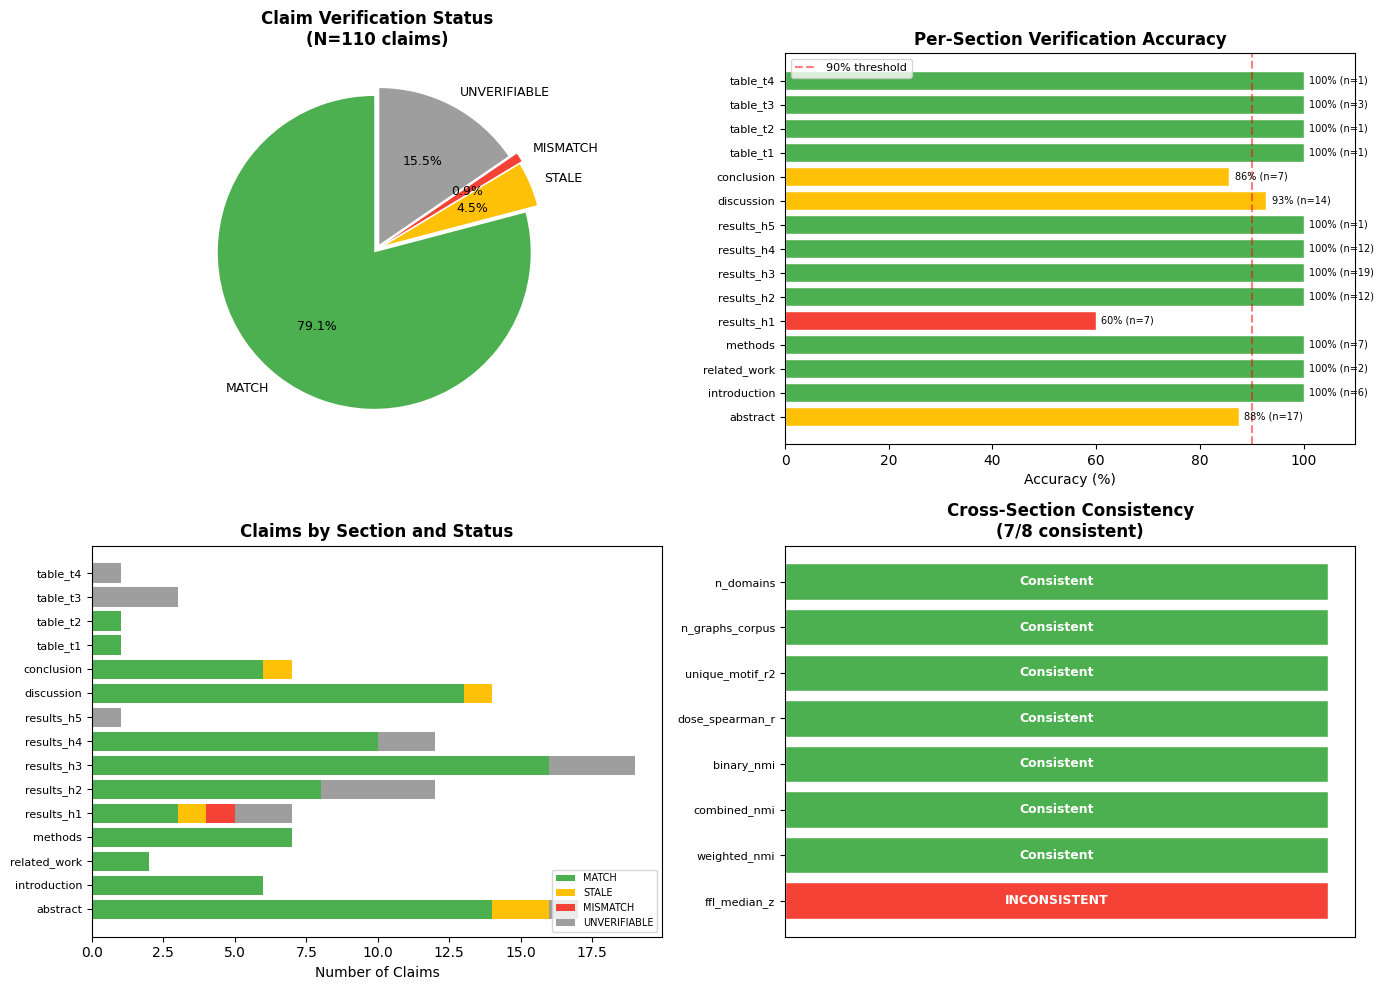

Saved verification_results.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Overall status distribution (pie chart) ---
ax = axes[0, 0]
agg = data["metrics_agg"]
labels = ["MATCH", "STALE", "MISMATCH", "UNVERIFIABLE"]
sizes = [agg["n_match"], agg["n_stale"], agg["n_mismatch"], agg["n_unverifiable"]]
colors = ["#4CAF50", "#FFC107", "#F44336", "#9E9E9E"]
explode = (0.03, 0.06, 0.08, 0.03)
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, explode=explode,
                                   autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
ax.set_title(f"Claim Verification Status\n(N={agg['total_claims']} claims)", fontsize=12, fontweight='bold')

# --- Plot 2: Per-section accuracy bar chart ---
ax = axes[0, 1]
sections_with_claims = {k: v for k, v in per_section.items() if v["n_claims"] > 0}
sec_names = list(sections_with_claims.keys())
sec_acc = [sections_with_claims[s]["accuracy_pct"] for s in sec_names]
sec_claims = [sections_with_claims[s]["n_claims"] for s in sec_names]
bar_colors = ["#4CAF50" if a == 100 else "#FFC107" if a >= 80 else "#F44336" for a in sec_acc]
bars = ax.barh(range(len(sec_names)), sec_acc, color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(sec_names)))
ax.set_yticklabels(sec_names, fontsize=8)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Per-Section Verification Accuracy", fontsize=12, fontweight='bold')
ax.set_xlim(0, 110)
for i, (acc, n) in enumerate(zip(sec_acc, sec_claims)):
    ax.text(acc + 1, i, f"{acc:.0f}% (n={n})", va='center', fontsize=7)
ax.axvline(x=90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
ax.legend(fontsize=8)

# --- Plot 3: Per-section stacked bar chart ---
ax = axes[1, 0]
match_vals = [sections_with_claims[s]["n_match"] for s in sec_names]
stale_vals = [sections_with_claims[s]["n_stale"] for s in sec_names]
mismatch_vals = [sections_with_claims[s]["n_mismatch"] for s in sec_names]
unver_vals = [sections_with_claims[s]["n_unverifiable"] for s in sec_names]
y_pos = range(len(sec_names))
ax.barh(y_pos, match_vals, color="#4CAF50", label="MATCH")
ax.barh(y_pos, stale_vals, left=match_vals, color="#FFC107", label="STALE")
left2 = [m + s for m, s in zip(match_vals, stale_vals)]
ax.barh(y_pos, mismatch_vals, left=left2, color="#F44336", label="MISMATCH")
left3 = [l + x for l, x in zip(left2, mismatch_vals)]
ax.barh(y_pos, unver_vals, left=left3, color="#9E9E9E", label="UNVERIFIABLE")
ax.set_yticks(y_pos)
ax.set_yticklabels(sec_names, fontsize=8)
ax.set_xlabel("Number of Claims")
ax.set_title("Claims by Section and Status", fontsize=12, fontweight='bold')
ax.legend(fontsize=7, loc='lower right')

# --- Plot 4: Consistency check results ---
ax = axes[1, 1]
metric_names = list(consistency.keys())
con_vals = [1 if consistency[m]["consistent"] else 0 for m in metric_names]
con_colors = ["#4CAF50" if v else "#F44336" for v in con_vals]
ax.barh(range(len(metric_names)), [1]*len(metric_names), color=con_colors, edgecolor='white')
ax.set_yticks(range(len(metric_names)))
ax.set_yticklabels(metric_names, fontsize=8)
ax.set_xticks([])
for i, (m, c) in enumerate(zip(metric_names, con_vals)):
    label = "Consistent" if c else "INCONSISTENT"
    ax.text(0.5, i, label, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white')
ax.set_title(f"Cross-Section Consistency\n({n_consistent}/{len(consistency)} consistent)",
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("verification_results.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved verification_results.png")